<a href="https://www.kaggle.com/code/tltommu/solution-masked-intent-inference-challenge?scriptVersionId=302884273" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [34]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from wordcloud import WordCloud
import re

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/tltommu/masked-intent-inference-challenge/sample_submission.csv
/kaggle/input/datasets/tltommu/masked-intent-inference-challenge/train.csv
/kaggle/input/datasets/tltommu/masked-intent-inference-challenge/test.csv


In [3]:
pd.read_csv('/kaggle/input/datasets/tltommu/masked-intent-inference-challenge/sample_submission.csv')

,id,prediction
0,0,neutral
1,37,neutral
2,80,neutral
3,101,neutral
4,110,neutral
...,...,...
19006,22398,neutral
19007,23821,neutral
19008,6816,neutral
19009,11983,neutral


In [4]:
pd.read_csv('/kaggle/input/datasets/tltommu/masked-intent-inference-challenge/test.csv')

,id,sentence
0,0,user we are the satanic sluts your parents war...
1,37,user user more user S9jc1VUqcRQMM about what s...
2,80,user there different type of arabs
3,101,and he was given a traditional moslem sea burial
4,110,i did not watch that far i saw men in skirts g...
...,...,...
19006,22398,i dont see any shoes on his feet after he land...
19007,23821,can we get a moment of silence for the passing...
19008,6816,þá var persaflóastríðið og miklir umbrotatímar...
19009,11983,youtube broadcast yourself


In [5]:
pd.read_csv('/kaggle/input/datasets/tltommu/masked-intent-inference-challenge/train.csv')

,id,sentence,category
0,0,its like they are gatekeeping tiredness so weird,neutral
1,1,rt argenivee its kinda s2dIANwutklEI how these...,offensive
2,2,personal insults arent allowed around here wee...,disapproval
3,3,now when i put this pussy on vivian she bet no...,offensive
4,4,sometime i wish i wasnt colored,offensive
...,...,...,...
231614,236733,downvoting for reupload please stop this nobod...,neutral
231615,236734,act like a worker think like a boss,not-sexist
231616,236735,it could nt have anything to do with ethnicity...,noHate
231617,236736,rt stonyxx give me conversationthey think u gi...,offensive


In [7]:
train = pd.read_csv('/kaggle/input/datasets/tltommu/masked-intent-inference-challenge/train.csv')
test = pd.read_csv('/kaggle/input/datasets/tltommu/masked-intent-inference-challenge/test.csv')

# Reading data and spotting data features

In [19]:
num_categories = train["category"].nunique()
print("Number of categories:", num_categories)
categories = train["category"].unique()
print(categories)
counts = train["category"].value_counts()
print(counts)

Number of categories: 49
['neutral' 'offensive' 'disapproval' 'DEG' 'anger' 'offensive intent'
 'sexist' 'optimism' 'surprise' 'not-sexist' 'non-offensive' 'hatespeech'
 'NDG' 'sadness' 'hate' 'confusion' 'joy' 'curiosity' 'lewd offensive'
 'caring' 'noHate' 'counterspeech' 'violent' 'approval' 'amusement'
 'admiration' 'annoyance' 'excitement' 'HOM' 'remorse' 'relief' 'fear'
 'desire' 'grief' 'peaceful' 'disappointment' 'gratitude' 'realization'
 'peace' 'unknown' 'relation' 'love' 'nervousness' 'disgust' 'APR'
 'embarrassment' 'CMP' 'pride' 'idk/skip']
category
neutral             35629
offensive           30423
DEG                 18514
non-offensive       18068
counterspeech       15712
NDG                 14991
offensive intent    13953
not-sexist          10264
hate                10048
hatespeech           9372
noHate               8059
admiration           4526
lewd offensive       3200
approval             2954
amusement            2495
annoyance            2407
gratitude     

# Plot

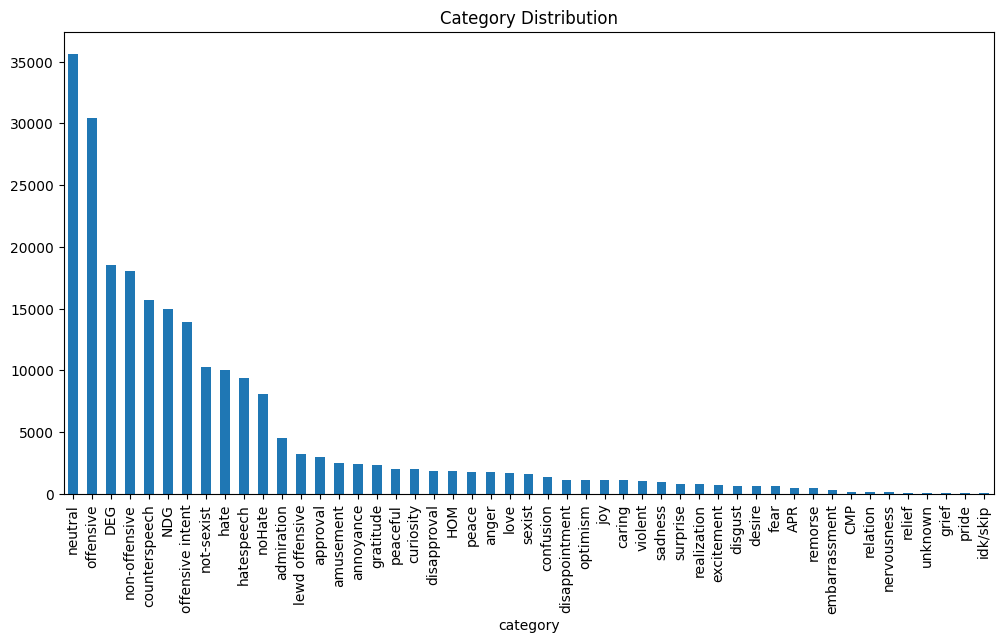

In [20]:
plt.figure(figsize=(12,6))
counts.plot(kind="bar")
plt.title("Category Distribution")
plt.show()

In [22]:
target_categories = [
    "APR",
    "remorse",
    "embarrassment",
    "CMP",
    "relation",
    "nervousness",
    "relief",
    "unknown",
    "grief",
    "pride",
    "idk/skip"
]

subset = train[train["category"].isin(target_categories)]

print(subset["category"].value_counts())

category
APR              495
remorse          442
embarrassment    279
CMP              152
relation         146
nervousness      121
relief            99
unknown           83
grief             73
pride             65
idk/skip          52
Name: count, dtype: int64


In [23]:
for cat in target_categories:
    print("\nCATEGORY:", cat)
    print(subset[subset["category"] == cat]["sentence"].head(5).tolist())


CATEGORY: APR
['i get hate from liberals for being a conservative and i get hate from conservatives for being a tranny i dont give a pSZCug im a god damn patriot and wont let this country fall to global elites', 'its not an sti they didnt sti make wagons from they couldve swapped the engine andor tranny but badging it is still kind of tacky', 'gt flaming faggot i wouldnt mind being a flaming faggot sounds kool so intense in removing hes on fire', 'i have to say a lot of the tranny women i see do act like men as a tranny myself i often wonder why why do tranz women start talking football why are there so many nerdgeek tranz women edit and why are so man tranz women lesbians', 'uj theres no RqGOpk6PCv7t6H difference between this place and rmadeofstyrofoam Wg8ZefTzhpd y0Nmgfl rj pwease validate my tranny ass until i cum in my cutss']

CATEGORY: remorse
['oh sorry to be clearer i meant everyone not on the app looking for a scooter will get sick of seeing random scooters', 'sorry i just go

In [24]:
def extract_keywords(texts, top_n=15):

    vectorizer = TfidfVectorizer(
        stop_words="english",
        max_features=5000,
        ngram_range=(1,2)
    )

    X = vectorizer.fit_transform(texts)

    scores = np.asarray(X.mean(axis=0)).ravel()

    terms = vectorizer.get_feature_names_out()

    top_indices = scores.argsort()[-top_n:][::-1]

    return [terms[i] for i in top_indices]

In [25]:
category_keywords = {}

for cat in target_categories:

    texts = subset[subset["category"] == cat]["sentence"]

    keywords = extract_keywords(texts)

    category_keywords[cat] = keywords

    print("\n", cat)
    print(keywords)


 APR
['faggot', 'tranny', 'im', 'like', 'just', 'dont', 'people', 'trannies', 'youre', 'know', 'trans', 'word', 'say', 'uj', 'gay']

 remorse
['sorry', 'im', 'im sorry', 'regret', 'dont', 'oh', 'didnt', 'just', 'like', 'bad', 'meant', 'apologies', 'feel', 'right', 'youre']

 embarrassment
['im', 'awkward', 'just', 'bad', 'oh', 'like', 'dont', 'embarrassment', 'weird', 'ashamed', 'feel', 'embarrassed', 'thats', 'youre', 'sorry']

 CMP
['video', 'post', 'sauce', 'guy', 'theres', 'like', 'posted', 'dude', 'reminds', 'nsfw', 'link', 'source', 'tranny', 'troll', 'used']

 relation
['white', 'black', 'just', 'people', 'nt', 'blacks', 'whites', 'great', 'think', 'like', 'africa', 'negro', 'live', 'asian', 'race']

 nervousness
['im', 'anxiety', 'just', 'like', 'stressed', 'know', 'worry', 'edgy', 'got', 'thats', 'dont', 'feel', 'makes', 'sub', 'people']

 relief
['im', 'cool', 'dont', 'feel', 'thank', 'didnt', 'better', 'good', 'relieved', 'just', 'god', 'wasnt', 'feel better', 'ok', 'safe']

In [32]:
stopwords = set(ENGLISH_STOP_WORDS)

def clean_text(text):

    text = text.lower()

    tokens = re.findall(r'\b\w+\b', text)

    tokens = [t for t in tokens if t not in stopwords]

    return " ".join(tokens)

In [37]:
for category in categories:

    texts = train[train["category"] == category]["sentence"]

    cleaned = texts.apply(clean_text)

    text_blob = " ".join(cleaned)

    plt.figure(figsize=(8,5))
    
    plt.hist(text_blob, bins=30)
    
    plt.title(f"Word Count Distribution for {category}")
    plt.xlabel("Number of Words")
    plt.ylabel("Frequency")
    
    plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Arabic natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12510 (\N{KATAKANA LETTER MA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 4367 (\N{HANGUL CHOSEONG KHIEUKH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52852 (\N{HANGUL SYLLABLE KA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/pyth

KeyboardInterrupt: 

In [ ]:
class_docs = []

labels = []

for cat in categories:

    texts = train[train["category"] == cat]["sentence"]

    class_docs.append(" ".join(texts))

    labels.append(cat)

In [ ]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,2),
    max_features=5000
)

X = vectorizer.fit_transform(class_docs)
words = vectorizer.get_feature_names_out()

In [ ]:
for i, cat in enumerate(labels):

    scores = X[i].toarray().flatten()

    top_indices = scores.argsort()[-15:][::-1]

    top_words = [words[j] for j in top_indices]

    print("\n",cat)
    print(top_words)